In [ ]:
#Google Sheets Linking (Needs user authorization)
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
!pip install pyspellchecker


In [ ]:
import pandas as pd

# Open the spreadsheet by URL
spreadsheet_url = 'https://docs.google.com/spreadsheets/d/14pMQzQwy2Dl9OIhS24hyJdX1sfEdVi9SeZfGuYaMKQ0/edit?usp=drive_link'
wb = gc.open_by_url(spreadsheet_url)
sheet = wb.get_worksheet(0)

# Load data into DataFrame
data = sheet.get_all_values()
df = pd.DataFrame(data[1:], columns=data[0])

print("Original Data:")
display(df.head())

Original Data:


,text,label_specific,label_generic
0,Hi\n\n I am running the IR test...,human_legit,legit
1,\n\n\n\n\n\n\n\n\n\n\n\n\nSecurity Note: Trade...,human_legit,legit
2,\n\n\n\n\n\n\n\n\n\nTrade Me Offer RequestGene...,human_legit,legit
3,"Hi Tony\nNot sure why it didn't work, but I ma...",human_legit,legit
4,Kindly suggest changes\n\n--------------------...,human_legit,legit


In [ ]:
import re

def phishing_preprocessor(text):
  # Remove the whitespace
  text = re.sub(r'\s+', ' ', text)
  # Remove special characters like '>', '="
  text = re.sub(r'[>=]', '', text) # This will remove '>' and '=' characters.
  # Replace more than 2 periods with a single period
  text = re.sub(r'\.{2,}', '.', text)
  return text

In [ ]:
df['text'] = df['text'].apply(phishing_preprocessor)
print("Data after applying phishing preprocessor:")
display(df.head())

Data after applying phishing preprocessor:


,text,label_specific,label_generic
0,Hi I am running the IR test program from Max D...,human_legit,legit
1,Security Note: Trade Me will never ask you fo...,human_legit,legit
2,"Trade Me Offer RequestGenerated 8 December, 6...",human_legit,legit
3,"Hi Tony Not sure why it didn't work, but I man...",human_legit,legit
4,Kindly suggest changes -----------------------...,human_legit,legit


In [ ]:
import re

def remove_foreign_characters(text):
    if isinstance(text, str):
        return re.sub(r'[^\x00-\x7F]+', '', text)
    return text

In [ ]:
#remove foreign characters
df['text'] = df['text'].apply(remove_foreign_characters)
print("Data after removing foreign characters:")
display(df.head())

Data after removing foreign characters:


,text,label_specific,label_generic
0,Hi I am running the IR test program from Max D...,human_legit,legit
1,Security Note: Trade Me will never ask you fo...,human_legit,legit
2,"Trade Me Offer RequestGenerated 8 December, 6...",human_legit,legit
3,"Hi Tony Not sure why it didn't work, but I man...",human_legit,legit
4,Kindly suggest changes -----------------------...,human_legit,legit


In [ ]:
#Average word count per message per category
df['word_count'] = df['text'].str.split().str.len()

average_word_count = df.groupby('label_specific')['word_count'].mean().reset_index()

print("Average word count per label:")
display(average_word_count)

Average word count per label:


,label_specific,word_count
0,human_legit,439.108
1,human_phishing,149.333
2,llm_legit,96.739
3,llm_phishing,97.834


In [ ]:
#Top 20 most common words per category
SKIPWORDS = set(['the', 'to', 'and', 'a', 'in', 'is', 'it', 'you', 'of', 'for', 'on', 'this', 'that', 'with', 'your', 'be', 'at'])

def get_top_words(group, n=20):
    # Join all text in the 'text' column for this specific group
    all_text = ' '.join(group['text'].astype(str)).lower()

    # Find words with 3 or more letters
    words = re.findall(r'\b[a-z]{3,}\b', all_text)

    # Filter out your SKIPWORDS
    filtered_words = [word for word in words if word not in SKIPWORDS]

    return Counter(filtered_words).most_common(n)

In [ ]:
top_words_per_cat = df.groupby('label_specific').apply(get_top_words)

# Print results
for label, top_20 in top_words_per_cat.items():
    print(f"\n--- Top 20 Words for {label} ---")
    print(top_20)


--- Top 20 Words for human_legit ---
[('submission', 27433), ('added', 10218), ('sender', 9894), ('notes', 9797), ('virus', 8799), ('same', 7911), ('total', 7440), ('trojan', 3182), ('http', 3161), ('org', 2959), ('already', 2153), ('detected', 2098), ('example', 1951), ('www', 1870), ('com', 1838), ('name', 1585), ('from', 1579), ('virscan', 1541), ('are', 1411), ('alias', 1380)]

--- Top 20 Words for human_phishing ---
[('email', 1706), ('monkey', 1676), ('account', 1632), ('org', 1606), ('jose', 1272), ('please', 1172), ('not', 919), ('will', 834), ('are', 798), ('information', 784), ('from', 755), ('message', 732), ('our', 699), ('have', 667), ('update', 616), ('mail', 612), ('all', 594), ('any', 562), ('has', 533), ('dear', 512)]

--- Top 20 Words for llm_legit ---
[('our', 1708), ('dear', 1000), ('com', 960), ('please', 956), ('https', 936), ('regards', 919), ('account', 850), ('finds', 796), ('email', 793), ('well', 717), ('security', 706), ('hope', 664), ('here', 618), ('thank

/tmp/ipython-input-3743797259.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_words_per_cat = df.groupby('label_specific').apply(get_top_words)


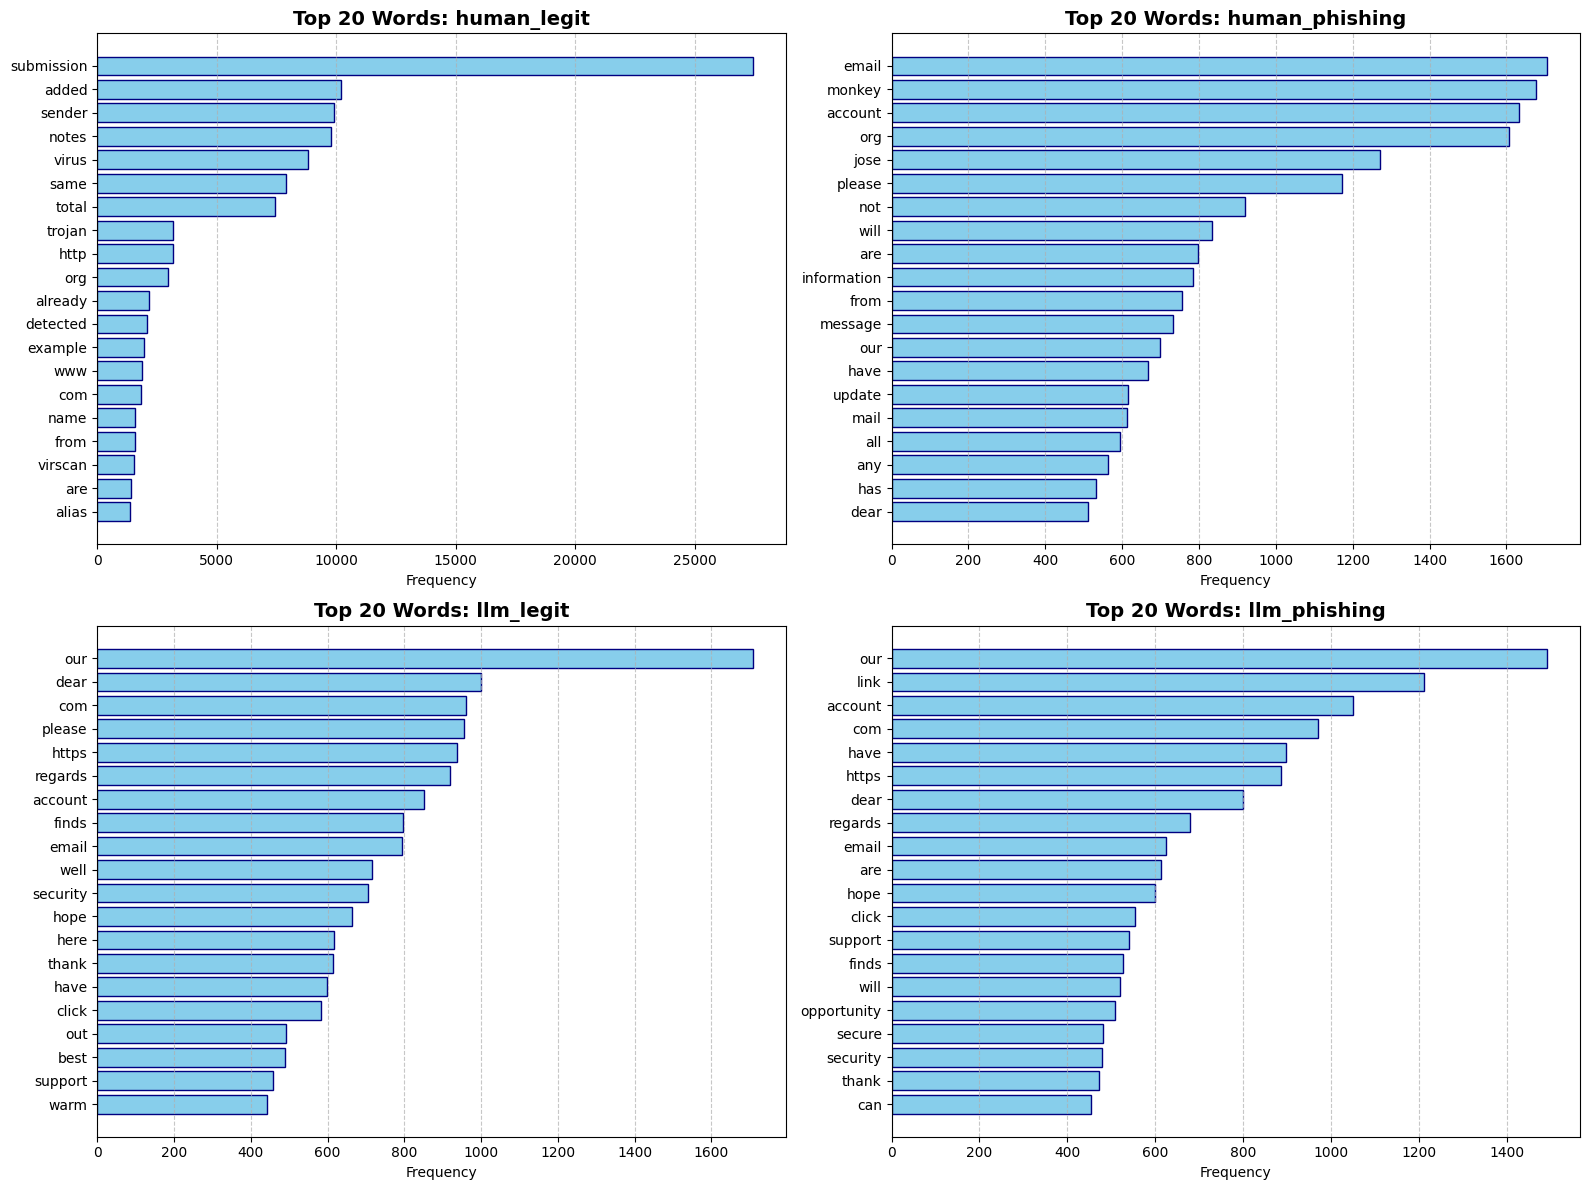

In [ ]:
# 1. Setup a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Flatten to easily loop through them

# 2. Iterate through each category's top words
for i, (label, word_list) in enumerate(top_words_per_cat.items()):
    # Prepare data (word_list is a list of tuples like [('email', 86), ...])
    # We reverse them [::-1] so the highest count is at the top of the chart
    words = [item[0] for item in word_list][::-1]
    counts = [item[1] for item in word_list][::-1]

    # Plot on the specific subplot
    axes[i].barh(words, counts, color='skyblue', edgecolor='navy')
    axes[i].set_title(f"Top 20 Words: {label}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Frequency')
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

# 3. Adjust layout so titles don't overlap
plt.tight_layout()
plt.show()

In [ ]:
#display the average character length per message per category
df['message_length'] = df['text'].apply(len)

average_message_length = df.groupby('label_specific')['message_length'].mean().reset_index()

print("Average message length per label:")
display(average_message_length)

Average message length per label:


,label_specific,message_length
0,human_legit,3294.269
1,human_phishing,1020.649
2,llm_legit,642.858
3,llm_phishing,650.122


In [ ]:
def count_capitalized_chars(text):
    if isinstance(text, str):
        return sum(1 for char in text if char.isupper())
    return 0

In [ ]:
#see average amount of capitalized characters per category
df['capitalized_chars_count'] = df['text'].apply(count_capitalized_chars)

average_capitalized_chars = df.groupby('label_specific')['capitalized_chars_count'].mean().reset_index()

print("Average capitalized characters per label:")
display(average_capitalized_chars)

Average capitalized characters per label:


,label_specific,capitalized_chars_count
0,human_legit,261.381
1,human_phishing,69.077
2,llm_legit,18.713
3,llm_phishing,16.788


In [ ]:
#Ratio of capitalized characters
df['capitalized_ratio'] = df['capitalized_chars_count'] / df['message_length']

average_capitalized_chars = df.groupby('label_specific')['capitalized_ratio'].mean().reset_index()

print("Ratio of capitalized characters per label:")
display(average_capitalized_chars)

Ratio of capitalized characters per label:


,label_specific,capitalized_ratio
0,human_legit,0.063260
1,human_phishing,0.065068
2,llm_legit,0.029880
3,llm_phishing,0.026602


In [ ]:
def count_shouting_instances(text):
  text = str(text)
  sequences = re.findall(r'[A-Z]{3,}', text)
  return len(sequences)

In [ ]:
#Find number of capitalized sequences
df['shouting_instances'] = df['text'].apply(count_shouting_instances)

average_shouting_instances = df.groupby('label_specific')['shouting_instances'].describe()

print("Average of shouting instances:")
display(average_shouting_instances)

Average of shouting instances:


,count,mean,std,min,25%,50%,75%,max
label_specific,,,,,,,,
human_legit,1000.0,12.000,25.948127,0.0,1.0,4.0,11.0,278.0
human_phishing,1000.0,4.437,10.967968,0.0,0.0,1.0,4.0,103.0
llm_legit,1000.0,0.317,0.771431,0.0,0.0,0.0,0.0,5.0
llm_phishing,1000.0,0.339,0.891557,0.0,0.0,0.0,0.0,6.0


In [ ]:
def count_url_links(text):
  text = str(text)
  url_pattern = r'(httos?://\S+|www\.\S+)'
  urls=re.findall(url_pattern,text)
  return len(urls)


In [ ]:
import matplotlib.pyplot as plt
df['text'].apply(count_url_links)

df['url_count'] = df['text'].apply(count_url_links)
labels_to_keep = ['human_legit', 'human_phishing', 'llm_legit']
df_sub = df[df['label_specific'].isin(labels_to_keep)].copy()
url_table = pd.crosstab(df_sub['label'], df_sub['url_count'])
print("URL Count Frequency Table (rows=label, cols=url_count):")
display(url_table)



url_table.plot(kind='bar', figsize=(10,6))
plt.title("URL Count Frequency Table")
plt.xlabel("Label")
plt.ylabel("Number of Emails")
plt.legend(title="url_count", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

KeyError: 'label'

# **Misspelled words**:
### Goal: find how the amount of misspelled words vary from each model.
1) Establish a function to find out how many mispelt words are in each email by using the spellchecker
2) Find the average of misspelled words per category
3) Find the density of misspelled words per category. This is given by the total amount of misspelled words in an email / the total word count

### Takeaways:
Noticed that while the human legit has the highest average of misspelt words, human phishing has the highest density of mispelt words by around 2x. On the other side, llm legit has almost no misspelt words

In [ ]:
#Find mispelled words
from spellchecker import SpellChecker
spell = SpellChecker()
known_list = ['https', 'http', 'html', 'url', 'unsubscribe', 'pdf', 'jpg', 'png']
spell.word_frequency.load_words(known_list)

def count_misspellings(text):
  words = re.findall(r'\b[a-z]+\b', str(text).lower())
  if not words:
    return 0

  misspelled = spell.unknown(words)
  return len(misspelled)

In [ ]:
#Find average of mispelled words
df['misspelled_words'] = df['text'].apply(count_misspellings)

average_misspelled_words = df.groupby('label_specific')['misspelled_words'].mean().reset_index()

print("Average of misspelled words:")
display(average_misspelled_words)

Average of misspelled words:


,label_specific,misspelled_words
0,human_legit,19.922
1,human_phishing,6.765
2,llm_legit,0.747
3,llm_phishing,4.206


In [ ]:
#Find density of misspelled words
df['density_mispelled'] = df['misspelled_words'] / df['word_count']

average_density_misspelled = df.groupby('label_specific')['density_mispelled'].mean().reset_index()

print("Average density of misspelled words:")
display(average_density_misspelled)

Average density of misspelled words:


,label_specific,density_mispelled
0,human_legit,0.082333
1,human_phishing,0.056894
2,llm_legit,0.008043
3,llm_phishing,0.040268


In [ ]:
#Save datasets
df.to_csv("group2_preprocessed.csv", index=False)